In [5]:
import pandas as pd

df_pib = pd.read_csv("../../Data/normalized_gdp.csv")
df_occupancy = pd.read_csv("../../Data/naip_occupancy_pixel_ratio_clean.csv")

In [6]:
df_pib.head()

,year,Nominal_GDP,inflation,Multiplier,Cumulative_Inflation_Index,Normalized_GDP
0,2012,40243,2.069337,1.020693,1.020693,39427
1,2013,40179,1.464833,1.014648,1.035645,38796
2,2014,41588,1.622223,1.016222,1.052445,39516
3,2015,51375,0.118627,1.001186,1.053694,48757
4,2016,52575,1.261583,1.012616,1.066987,49274


In [7]:
df_occupancy.head()

,store_id,date,occupancy,year
0,42,2012-06-22,0.045929,2012
1,42,2015-08-20,0.030685,2015
2,42,2023-06-06,0.015762,2023
3,115,2010-08-09,0.024048,2010
4,115,2013-08-07,0.012054,2013


In [8]:
df_pib = df_pib[df_pib["year"] < 2023]
df_occupancy = df_occupancy[df_occupancy["year"] < 2023]

--------------------------------------------------
El coeficiente de correlación de Pearson es: 0.7956
--------------------------------------------------


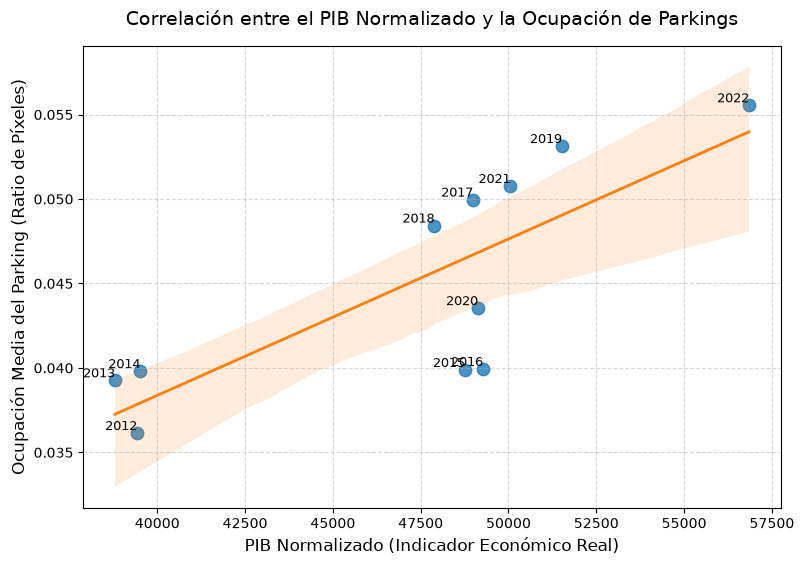

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Agrupar la ocupación por año (calculamos la media anual de todos los parkings)
# Asegúrate de que el nombre de la columna 'year' coincida en mayúsculas/minúsculas
df_occ_yearly = df_occupancy.groupby('year')['occupancy'].mean().reset_index()

# 3. Fusionar ambos DataFrames usando el año como nexo
# Nos quedamos solo con las columnas que nos interesan
df_correlation = pd.merge(df_occ_yearly, df_pib[['year', 'Normalized_GDP']], on='year')

# 4. CALCULAR LA CORRELACIÓN DE PEARSON
correlation_matrix = df_correlation[['Normalized_GDP', 'occupancy']].corr()
correlation_value = correlation_matrix.loc['Normalized_GDP', 'occupancy']

print("-" * 50)
print(f"El coeficiente de correlación de Pearson es: {correlation_value:.4f}")
print("-" * 50)

# 5. VISUALIZACIÓN: Gráfico de dispersión con línea de tendencia
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_correlation, 
    x='Normalized_GDP', 
    y='occupancy', 
    scatter_kws={'s': 80, 'color': '#1f77b4', 'alpha': 0.8},
    line_kws={'color': '#ff7f0e', 'linewidth': 2}
)

# Añadir los años como etiquetas a los puntos para identificar anomalías (como el 2020)
for i in range(df_correlation.shape[0]):
    plt.text(
        df_correlation['Normalized_GDP'].iloc[i], 
        df_correlation['occupancy'].iloc[i], 
        str(int(df_correlation['year'].iloc[i])),
        verticalalignment='bottom', 
        horizontalalignment='right',
        fontsize=9
    )

plt.title('Correlación entre el PIB Normalizado y la Ocupación de Parkings', fontsize=14, pad=15)
plt.xlabel('PIB Normalizado (Indicador Económico Real)', fontsize=12)
plt.ylabel('Ocupación Media del Parking (Ratio de Píxeles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.show()